# Logistic Regression

### Import Libraries

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('logistic_reg.csv')
df.head(10)

,x1,x2,label
0,21.476623,14.015911,1.0
1,-26.951466,-13.747162,0.0
2,4.287420,-11.628341,0.0
3,-17.295981,-23.864650,0.0
4,22.682159,20.769558,1.0
5,-4.400252,-1.399145,0.0
6,10.469592,2.609161,0.0
7,27.468712,26.992179,1.0
8,22.039176,5.459492,1.0
9,5.596212,0.753507,0.0


<Axes: xlabel='x1', ylabel='x2'>

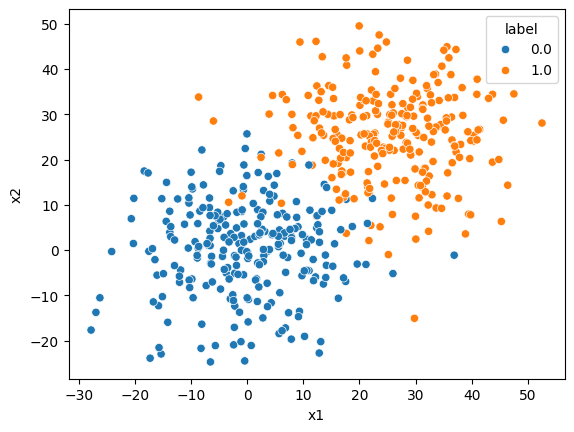

In [3]:
sns.scatterplot(x=df['x1'],y=df['x2'],hue=df['label'])

In [4]:
from sklearn.linear_model import LogisticRegression

In [5]:
X = df[['x1','x2']].to_numpy()
X[:10]

array([[ 21.47662337,  14.01591057],
       [-26.95146623, -13.74716174],
       [  4.28741975, -11.62834092],
       [-17.29598115, -23.86465033],
       [ 22.68215901,  20.76955807],
       [ -4.40025196,  -1.39914457],
       [ 10.46959233,   2.60916147],
       [ 27.46871175,  26.99217923],
       [ 22.03917627,   5.45949198],
       [  5.59621215,   0.75350749]])

In [6]:
y = df['label'].to_numpy()
y[:10]

array([1., 0., 0., 0., 1., 0., 0., 1., 1., 0.])

In [7]:
reg = LogisticRegression()
reg.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [8]:
reg.coef_

array([[0.24692372, 0.26467808]])

In [9]:
reg.intercept_

array([-6.38857843])

The result of the linear regression is the coefficients $\theta$ 's of the equation:
<br><br>
<center>$h(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + ... + \theta_n x_n$</center>

* `coef_` returns a list of $\theta_1, \theta_2, ... , \theta_n$
* `intercept_` returns the value of $\theta_0$

In the previous example, we have $x_1$ and $x_2$, thus two coefficients $\theta_1$ and $\theta_2$

To draw the line separating the 2 datasets, we just have to replace the coefficients and intercept in this equation:

$\theta_0 + \theta_1 x_1 + \theta_2 x_2 = 0$

$x_2 = -(\theta_0 + \theta_1 x_1) / \theta_2 $


<Axes: xlabel='x1', ylabel='x2'>

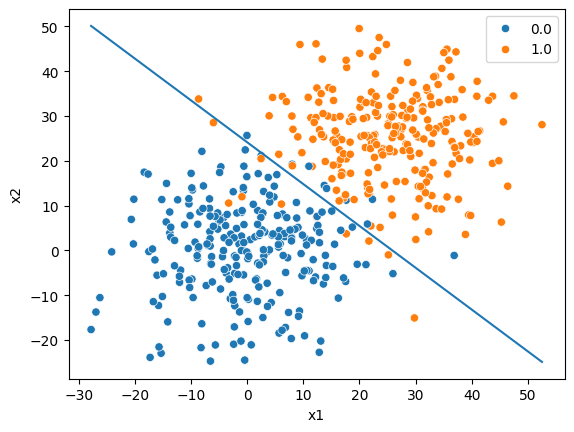

In [10]:
theta0 = reg.intercept_
theta1 = reg.coef_[0,0]
theta2 = reg.coef_[0,1]

x2 = -(theta0+theta1*df['x1'])/theta2
sns.scatterplot(x=df['x1'],y=df['x2'],hue=df['label'])
sns.lineplot(x=df['x1'],y=x2)

<hr />

### How to predict new values?

if you have a value of $x$, you can either replace the value in previous $h(x)$ equation, and check if the value is less or more than 0, or use `predict` function below:

In [11]:
reg.predict([
                [0,40],
                [0,-10]
            ])
#first belongs to class 1, second to class 0

array([1., 0.])